In [1]:
import cv2

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)


In [2]:
# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    cv2.imshow(f'Thresholded Image ({threshold_value})', thresh)



In [ ]:
# Display the original image
cv2.imshow('Original Image', img)
cv2.waitKey(0)
cv2.destroyAllWindows() 

In [3]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data, img_as_float
from skimage import exposure

# Step#2: Load moon image
img = data.moon()


In [4]:
# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))


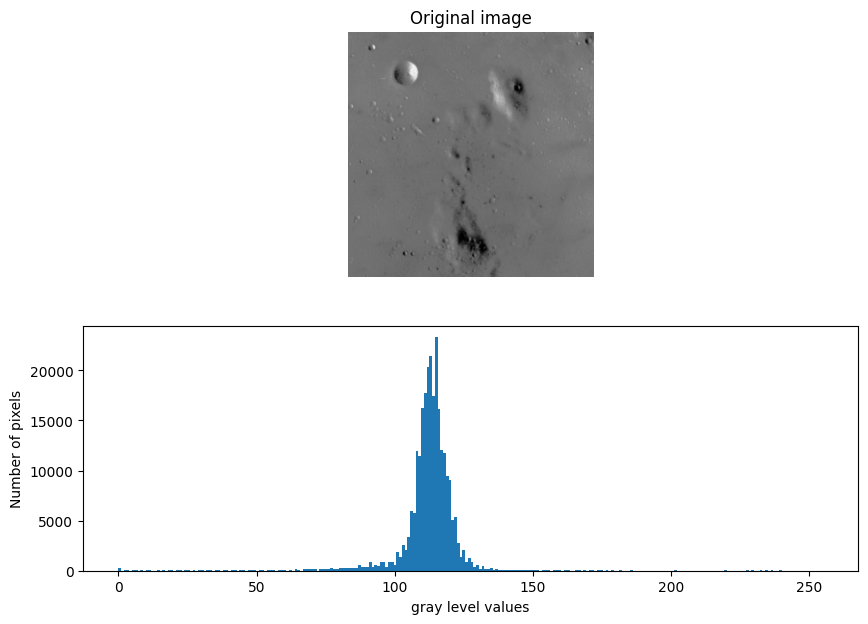

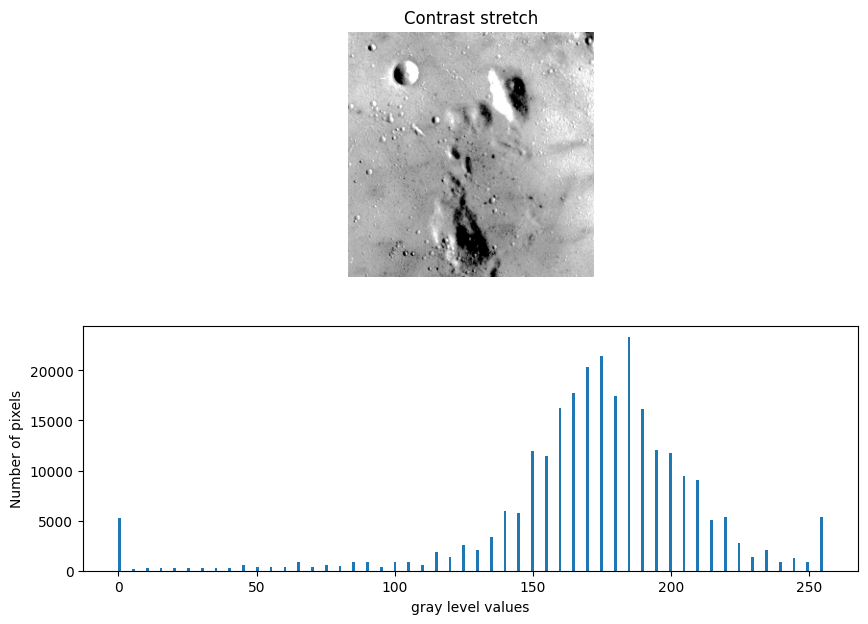

In [5]:
# Step#4: Display the image with its histogram of (step#2)  and (step#3)

fig = plt.figure(figsize=(10, 7)) 
fig.add_subplot(2, 1, 1) 
plt.imshow(img, cmap = 'gray') 
plt.axis('off') 
plt.title('Original image') 
fig.add_subplot(2, 1, 2) 
plt.hist(img.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show() 
fig = plt.figure(figsize=(10, 7)) 
fig.add_subplot(2, 1, 1) 
plt.imshow(img_rescale, cmap = 'gray') 
plt.axis('off') 
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2) 
plt.hist(img_rescale.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show() 

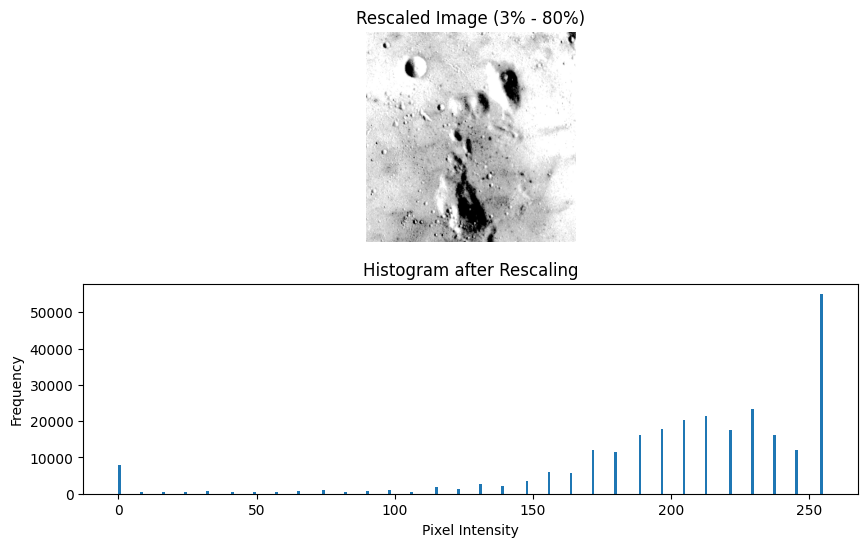

In [ ]:
# Task#1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure

moon_image = data.moon()

low_percentile, high_percentile = np.percentile(moon_image, (3, 80))

rescaled_output = exposure.rescale_intensity(moon_image, in_range=(low_percentile, high_percentile))

plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.imshow(rescaled_output, cmap='gray')
plt.title("Rescaled Image (3% - 80%)")
plt.axis('off')

plt.subplot(2,1,2)
plt.hist(rescaled_output.flat, bins=256)
plt.title("Histogram after Rescaling")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

# Task#2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

# Task#3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


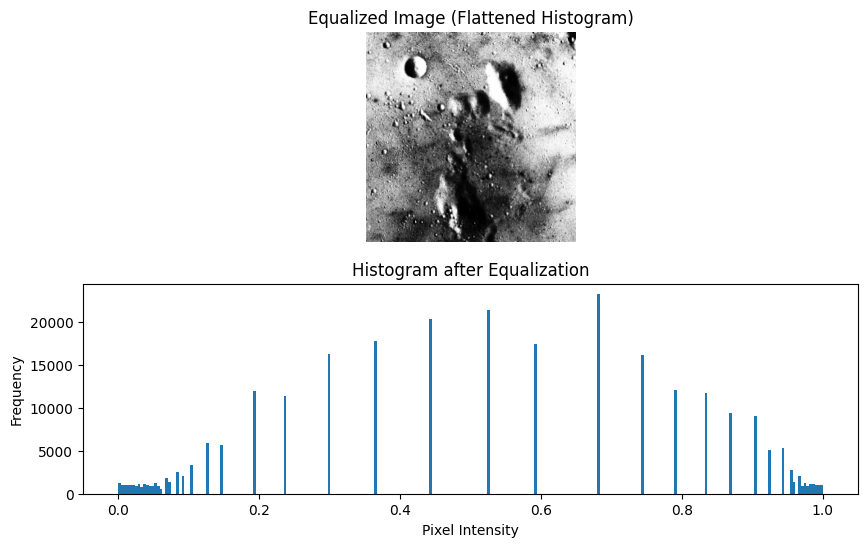

In [13]:
# Task#2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.
import matplotlib.pyplot as plt
from skimage import data, exposure

moon_image = data.moon()

equalized_output = exposure.equalize_hist(moon_image)

plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.imshow(equalized_output, cmap='gray')
plt.title("Equalized Image (Flattened Histogram)")
plt.axis('off')

plt.subplot(2,1,2)
plt.hist(equalized_output.flat, bins=256)
plt.title("Histogram after Equalization")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

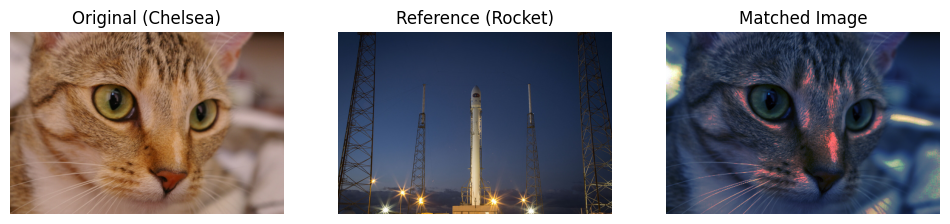

In [14]:
#Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching
import matplotlib.pyplot as plt
from skimage import data
from skimage.exposure import match_histograms

source_photo = data.chelsea()
target_photo = data.rocket()

matched_output = match_histograms(source_photo, target_photo, channel_axis=-1)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(source_photo)
plt.title("Original (Chelsea)")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(target_photo)
plt.title("Reference (Rocket)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(matched_output)
plt.title("Matched Image")
plt.axis('off')

plt.show()